In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

# Load and split data (same as your training notebook)
iris = load_iris()
X, y = iris.data, iris.target

# 70/15/15 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Scale (fit on train only!)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [2]:
# Best hyperparams found during validation — adjust if yours differ
best_k = 5
best_metric = 'euclidean'

model = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
model.fit(X_train_s, y_train)

KNeighborsClassifier(metric='euclidean')

In [3]:
y_pred = model.predict(X_test_s)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print()
print("Full classification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy : 0.9130
Precision: 0.9333
Recall   : 0.9167
F1-score : 0.9153

Full classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       0.80      1.00      0.89         8
   virginica       1.00      0.75      0.86         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23



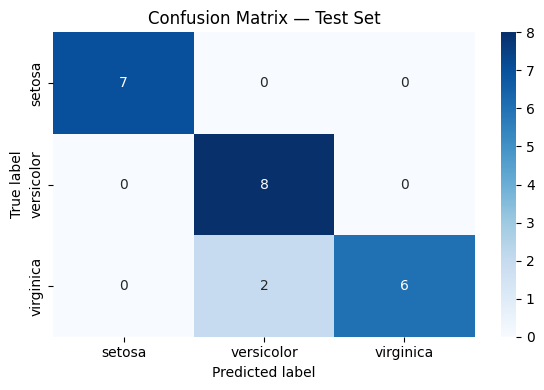

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

ROC-AUC (macro OvR): 0.9889


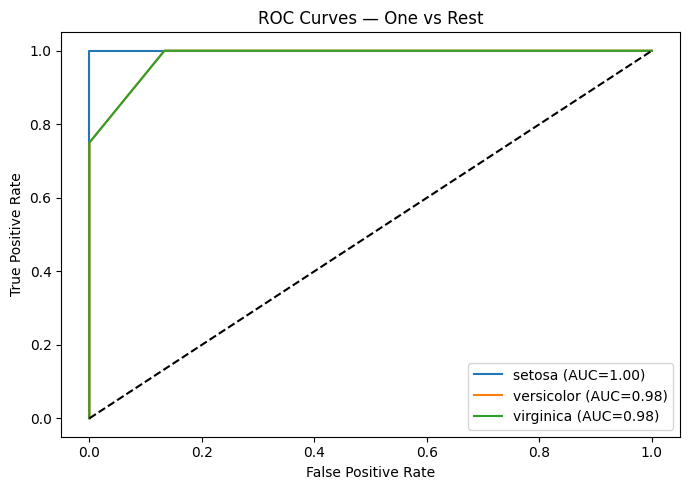

In [6]:
# Need probability scores
model_prob = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
model_prob.fit(X_train_s, y_train)
y_prob = model_prob.predict_proba(X_test_s)

# Binarize labels for OvR ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

roc_auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
print(f"ROC-AUC (macro OvR): {roc_auc:.4f}")

# Plot per-class ROC curves
plt.figure(figsize=(7, 5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{iris.target_names[i]} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — One vs Rest')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# LOO runs on the FULL dataset (standard practice)
X_scaled_full = scaler.fit_transform(X)

loo = LeaveOneOut()
loo_model = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)

loo_scores = cross_val_score(loo_model, X_scaled_full, y, cv=loo, scoring='accuracy')

print(f"LOO-CV Accuracy: {loo_scores.mean():.4f} ± {loo_scores.std():.4f}")
print(f"Number of folds: {len(loo_scores)}")  # should be 150 for Iris

LOO-CV Accuracy: 0.9467 ± 0.2247
Number of folds: 150
